# 🛠️ TEMPLATE HUẤN LUYỆN MÔ HÌNH (Dành cho Team 5 người)

**Quy định chung của nhóm (Trưởng nhóm yêu cầu):**
1. Tất cả thành viên phải copy file template này thành file riêng của mình (VD: `05A_Logistic.ipynb`, `05B_RandomForest.ipynb`...).
2. **KHÔNG** được thay đổi phần 1 (Load Data) và phần 2 (Chia Train/Test) để đảm bảo mọi người cùng thi trên một bộ dữ liệu.
3. Tất cả phải sử dụng hàm `evaluate_model` ở phần 3 để in ra kết quả cuối cùng (F1, Recall, Precision).
4. Phần 4 là khu vực làm việc riêng của từng người.

## 1. Import Thư viện & Load Dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Load file Master (Sạch 100%)
df = pd.read_csv('../dataMaster/gym_churn_master_final.csv')

# Xóa các cột định danh không có ý nghĩa dự báo
df_ml = df.drop(columns=['short_p_id', 'customer_postal'])

# Chuyển đổi các biến phân loại (Categorical) thành biến giả (Dummy/One-Hot)
# Các cột cần chuyển: gender, main_density_class
df_ml = pd.get_dummies(df_ml, columns=['gender', 'main_density_class'], drop_first=True)

print(f"Kích thước dữ liệu sau khi chuẩn bị: {df_ml.shape}")

Kích thước dữ liệu sau khi chuẩn bị: (6327, 22)


## 2. Chia Dữ Liệu (Train / Test Split)
🚨 **LƯU Ý:** Tuyệt đối không sửa `random_state=42` để đảm bảo kết quả đồng nhất cả nhóm.

In [2]:
# Tách biến mục tiêu (y) và biến đặc trưng (X)
# LƯU Ý: Loại bỏ 'recency' để tránh hiện tượng Data Leakage (Rò rỉ dữ liệu)
X = df_ml.drop(columns=['is_churn', 'recency'])
y = df_ml['is_churn']

# Chia tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Số lượng tập Train: {X_train.shape[0]} dòng")
print(f"Số lượng tập Test: {X_test.shape[0]} dòng")
print("\nTỷ lệ Churn trong tập Train:")
print(y_train.value_counts(normalize=True))

Số lượng tập Train: 5061 dòng
Số lượng tập Test: 1266 dòng

Tỷ lệ Churn trong tập Train:
is_churn
1    0.781466
0    0.218534
Name: proportion, dtype: float64


## 3. Hàm Đánh Giá Chung Cho Cả Nhóm
Hàm này dùng để in ra các chỉ số metric và vẽ Confusion Matrix một cách thống nhất.

In [3]:
def evaluate_model(model_name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f" KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: {model_name}")
    print(f"{'='*40}")
    print("\n1. Phân loại tổng quát (Classification Report):")
    print(classification_report(y_true, y_pred))
    
    print("2. Chỉ số quan trọng nhất (Macro F1-Score):")
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"-> {f1:.4f}")
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Dự báo: Ở lại', 'Dự báo: Nghỉ'],
                yticklabels=['Thực tế: Ở lại', 'Thực tế: Nghỉ'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

## 4. Khu Vực Làm Việc Riêng (Ví dụ: Logistic Regression - Trưởng Nhóm)
*(Các thành viên khác sẽ viết code mô hình của mình từ phần này trở đi)*


 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Logistic Regression (Baseline)

1. Phân loại tổng quát (Classification Report):
              precision    recall  f1-score   support

           0       0.31      0.64      0.42       277
           1       0.86      0.60      0.71       989

    accuracy                           0.61      1266
   macro avg       0.58      0.62      0.56      1266
weighted avg       0.74      0.61      0.64      1266

2. Chỉ số quan trọng nhất (Macro F1-Score):
-> 0.5615


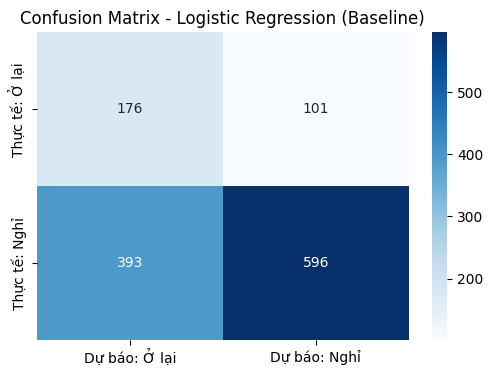

In [4]:
from sklearn.linear_model import LogisticRegression

# 4.1 Chuẩn hóa dữ liệu (QUAN TRỌNG cho Logistic, SVM, MLP)
# Lưu ý: Fit trên Train, Transform trên cả Train và Test để tránh Data Leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4.2 Khởi tạo và Huấn luyện mô hình Baseline
# Dùng class_weight='balanced' vì dữ liệu mất cân bằng (78% Churn)
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# 4.3 Dự báo trên tập Test
y_pred_lr = lr_model.predict(X_test_scaled)

# 4.4 Đánh giá bằng hàm chung của nhóm
evaluate_model("Logistic Regression (Baseline)", y_test, y_pred_lr)

### Phân tích thêm dành cho Trưởng Nhóm (Feature Importance của Logistic Regression)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_31440\3947327918.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(10), palette='coolwarm')


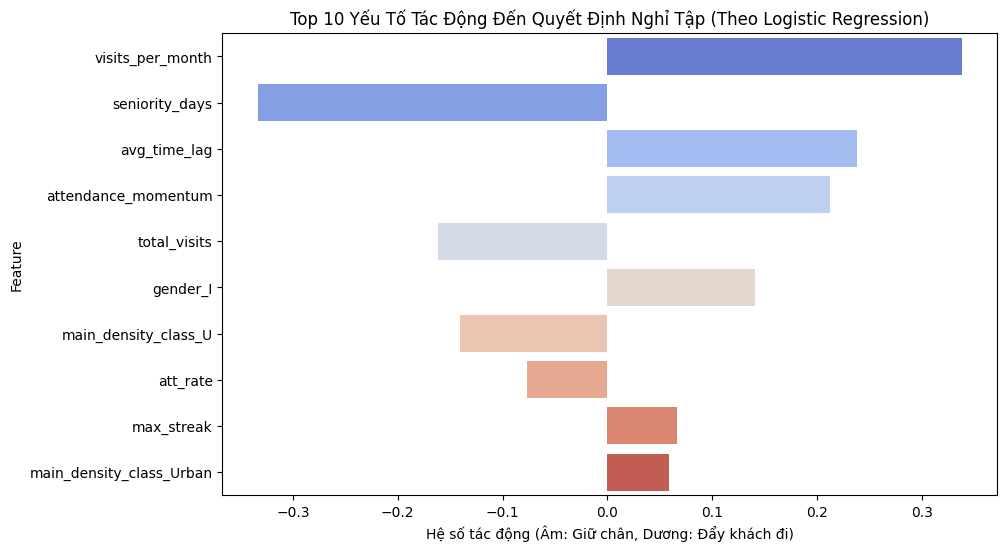

In [5]:
# Lấy hệ số của mô hình Logistic để xem biến nào tác động mạnh nhất đến việc Churn
feature_names = X.columns
coefficients = lr_model.coef_[0]

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coef', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(10), palette='coolwarm')
plt.title('Top 10 Yếu Tố Tác Động Đến Quyết Định Nghỉ Tập (Theo Logistic Regression)')
plt.xlabel('Hệ số tác động (Âm: Giữ chân, Dương: Đẩy khách đi)')
plt.show()

### 4.5 Tối ưu hóa siêu tham số bằng GridSearchCV (Nâng cao dành cho Trưởng Nhóm)

Đang tiến hành quét tham số tối ưu (Grid Search CV)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Tham số tốt nhất tìm được: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Điểm F1-Macro trung bình tốt nhất trên tập CV: 0.5474

 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Logistic Regression (GridSearchCV Optimized)

1. Phân loại tổng quát (Classification Report):
              precision    recall  f1-score   support

           0       0.30      0.64      0.41       277
           1       0.85      0.58      0.69       989

    accuracy                           0.60      1266
   macro avg       0.58      0.61      0.55      1266
weighted avg       0.73      0.60      0.63      1266

2. Chỉ số quan trọng nhất (Macro F1-Score):
-> 0.5519


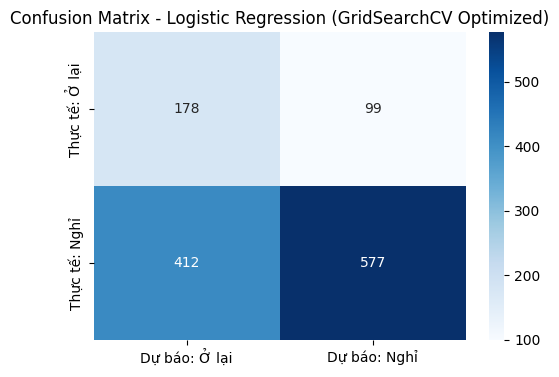

In [6]:
from sklearn.model_selection import GridSearchCV

# Định nghĩa lưới tham số cần quét (Grid)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear hỗ trợ tốt cả l1 và l2 cho tập dữ liệu nhỏ
}

# Khởi tạo GridSearchCV với K-Fold CV = 5
# Sử dụng scoring='f1_macro' để tối ưu hóa đồng đều cho cả 2 nhóm (Active & Churn)
grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

print("Đang tiến hành quét tham số tối ưu (Grid Search CV)...")
grid_search.fit(X_train_scaled, y_train)

# In tham số tốt nhất
print("\nTham số tốt nhất tìm được:", grid_search.best_params_)
print(f"Điểm F1-Macro trung bình tốt nhất trên tập CV: {grid_search.best_score_:.4f}")

# Dự báo bằng mô hình đã tối ưu hóa tốt nhất
best_lr = grid_search.best_estimator_
y_pred_best = best_lr.predict(X_test_scaled)

# Đánh giá mô hình đã tối ưu
evaluate_model("Logistic Regression (GridSearchCV Optimized)", y_test, y_pred_best)